# Detección de objetos con YOLOv11

YOLO (You Only Look Once) es una familia de modelos de detección de objetos en tiempo real. En esta sección, se muestra cómo utilizar un modelo YOLOv11 para detectar objetos en imágenes.

In [9]:
from ultralytics import YOLO
from roboflow import Roboflow
import matplotlib.pyplot as plt

In [10]:
# Load a pretrained YOLO11 model
model_s = YOLO("yolo11s.pt")
model_m = YOLO("yolo11m.pt")
model_l = YOLO("yolo11l.pt")

Descarga del dataset personalizado desde Roboflow

In [11]:
# Codigo generado por Roboflow para descargar el dataset personalizado
rf = Roboflow(api_key="bnn4fW4vv3ttWTv1EVOq")
project = rf.workspace("vision-computer-h1dah").project("yo-g5uyc")
version = project.version(3)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


Entrenamiento

In [12]:
results = model_s.train(
    data=f"{dataset.location}/data.yaml",
    epochs=10,
    imgsz=640,
    batch=1,
    project="runs",
    name="custom_yo",
    exist_ok=True,
)

Ultralytics 8.4.37 🚀 Python-3.12.8 torch-2.11.0+cu130 CPU (11th Gen Intel Core i7-11850H @ 2.50GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/comejia/projects/ceia/ceia-computer-vision-ii/2026/Clase_4/yo-3/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=custom_yo, nbs=64, nms=False, opset=No

In [13]:
metrics = model_s.val(imgsz=640, project="runs", name="custom_yo", exist_ok=True, plots=True)

print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")
print(f"Precision por clase: {metrics.box.maps}")

Ultralytics 8.4.37 🚀 Python-3.12.8 torch-2.11.0+cu130 CPU (11th Gen Intel Core i7-11850H @ 2.50GHz)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2321.6±1756.9 MB/s, size: 36.8 KB)
val: Scanning /home/comejia/projects/ceia/ceia-computer-vision-ii/2026/Clase_4/yo-3/valid/labels.cache... 2 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2/2 762.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.3it/s 0.4s
                   all          2          2    0.00292        0.5      0.124     0.0498
                 cesar          1          1          0          0          0          0
                    pc          1          1    0.00585          1      0.249     0.0995
Speed: 0.7ms preprocess, 93.4ms inference, 0.0ms loss, 120.4ms postprocess per image
Results saved to /home/comejia/projects/ceia/ceia-computer-vision-ii/runs/

In [14]:
import os
import pandas as pd

base_path = "../../runs/detect/runs/custom_yo"
results_path = os.path.join(base_path, "results.csv")

df = pd.read_csv(results_path)

df

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,2.73420,1.37334,10.83450,1.31905,0.01671,0.5,0.16583,0.06633,2.18077,5.53511,2.76919,0.000056,0.000056,0.000056
1,2,5.51649,1.39598,9.16694,1.16236,0.00254,0.5,0.08292,0.03420,2.02844,6.49865,2.54096,0.000110,0.000110,0.000110
2,3,8.38074,1.91617,12.73800,1.48182,0.00254,0.5,0.08292,0.03420,2.02844,6.49865,2.54096,0.000151,0.000151,0.000151
3,4,11.82760,1.89567,9.82220,1.72433,0.00243,0.5,0.00957,0.00383,1.79211,8.39232,2.07993,0.000180,0.000180,0.000180
4,5,14.75980,1.77638,6.27772,1.30050,0.00243,0.5,0.00957,0.00383,1.79211,8.39232,2.07993,0.000195,0.000195,0.000195
5,6,17.69900,1.31608,7.09464,1.49193,0.00243,0.5,0.00957,0.00383,1.79211,8.39232,2.07993,0.000196,0.000196,0.000196
6,7,20.90060,1.98183,6.28820,1.70649,0.00243,0.5,0.00957,0.00383,1.79211,8.39232,2.07993,0.000185,0.000185,0.000185
7,8,23.88730,0.84643,9.06267,0.65932,0.00243,0.5,0.00957,0.00383,1.79211,8.39232,2.07993,0.000160,0.000160,0.000160
8,9,27.02550,1.21435,8.53665,1.01726,0.00243,0.5,0.00957,0.00383,1.79211,8.39232,2.07993,0.000122,0.000122,0.000122
9,10,30.19290,1.24313,8.45030,1.24202,0.01015,1.0,0.01597,0.00541,1.93229,8.19872,2.66636,0.000071,0.000071,0.000071


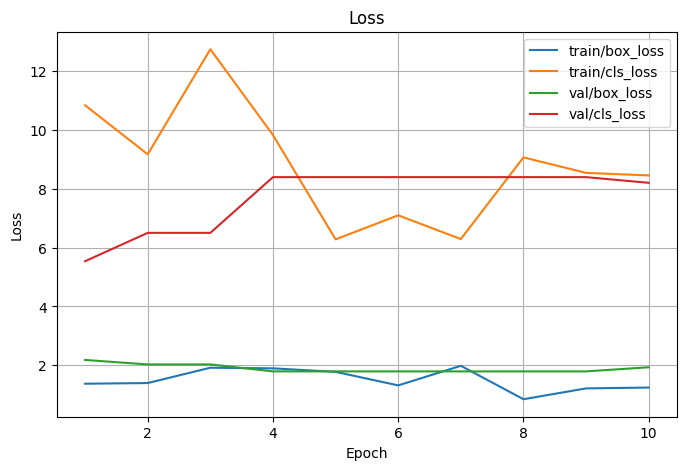

In [15]:
# Box loss: que tan bien ajusta el modelo el bounding box a los objetos detectados.
# Class loss: que tan bien clasifica el modelo los objetos detectados.


plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["train/box_loss"], label="train/box_loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="train/cls_loss")
plt.plot(df["epoch"], df["val/box_loss"], label="val/box_loss")
plt.plot(df["epoch"], df["val/cls_loss"], label="val/cls_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()

Predicción

In [16]:
image_path = "./cesar_mejia.jpeg"

results = model_s.predict(
    source=image_path,
    device="cpu",
    conf=0.5,
    imgsz=640,
    verbose=True,
    project="runs",
    name="custom_yo",
    exist_ok=True,
)

r = results[0]

annotated = r.plot()[:, :, ::-1]


image 1/1 /home/comejia/projects/ceia/ceia-computer-vision-ii/2026/Clase_4/cesar_mejia.jpeg: 640x608 1 rostro, 147.1ms
Speed: 3.4ms preprocess, 147.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 608)


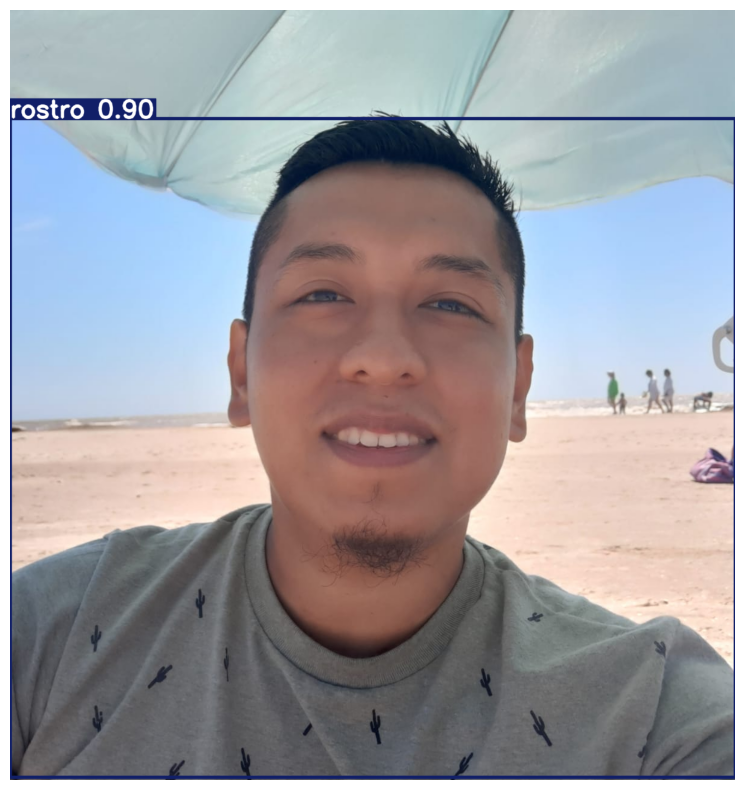

In [18]:
def plot_detections(annotated):
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated)
    plt.axis("off")
    plt.show()


plot_detections(annotated)